<a href="https://colab.research.google.com/github/mariaposada2002/Proyecto_PDI_FINAL/blob/main/PROYECTO_PDI_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final: Despertador Inteligente Anti-Snooze con Validación de Objetos (YOLOv11)
## Maria Isabel Posada Niasa, Lina Robsana Jamioy
## Fase 1: Configuración del Entorno e Instalación de Dependencias

En esta sección se inicializa el entorno de ejecución de Google Colab instalando las librerías fundamentales para el desarrollo del despertador interactivo basado en Visión por Computador:
* **Roboflow**: Utilizada para la gestión, control de versiones y descarga automatizada del dataset de calibración del hogar mediante API.
* **Ultralytics**: Framework que contiene la implementación nativa, arquitecturas y herramientas de entrenamiento/exportación de la familia de modelos YOLOv11 (You Only Look Once).
* **NumPy & Matplotlib**: Bibliotecas indispensables para el procesamiento eficiente de arreglos multidimensionales (imágenes) y la visualización de los resultados de detección.

In [1]:
# %%capture es un comando mágico de IPython que oculta la salida de la consola
# (logs de instalación), manteniendo el notebook limpio y legible.
%%capture

# Instalación del SDK oficial de Roboflow para la extracción del dataset alojado en la nube
!pip install roboflow

# Instalación del ecosistema Ultralytics para el uso de YOLOv11 (entrenamiento, evaluación e inferencia)
!pip install ultralytics

# Instalación/Actualización de NumPy para la manipulación y álgebra lineal de matrices de pixeles
!pip install numpy

## Fase 2: Importación de Módulos y Configuración del Entorno de Ejecución

En este bloque se cargan todas las librerías necesarias para estructurar el pipeline de desarrollo. El objetivo es importar los módulos de sistema, manejo de archivos de configuración, procesamiento matemático, visualización de datos y el motor de Deep Learning.

Adicionalmente, se configuran las variables de entorno globales del sistema para optimizar los tiempos de ejecución, mitigando interrupciones por herramientas externas de telemetría.

In [2]:
# Módulos del Sistema y Manejo de Archivos
import os
import yaml
import glob

# Framework de Deep Learning y Tensores
import torch

# Ecosistema de Visión por Computador y Modelado
from roboflow import Roboflow
from ultralytics import YOLO
import wandb

# Procesamiento Numérico y Visualización Gráfica
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image, display

# --- CONFIGURACIÓN DE VARIABLES DE ENTORNO ---
# Desactivación explícita de Weights & Biases (W&B) para evitar peticiones de login interactivo
# y asegurar que el entrenamiento se ejecute de manera continua en la infraestructura local.
os.environ['WANDB_DISABLED'] = 'true'

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Fase 3: Adquisición y Descarga del Dataset desde Roboflow

En esta etapa se realiza la conexión remota con la plataforma **Roboflow** utilizando una clave de API autenticada para descargar el conjunto de datos estructurado y preprocesado.

Este dataset contiene las imágenes de ambientes domésticos etiquetadas y clasificadas específicamente para calibrar la lógica de nuestro **Despertador Inteligente**, distribuyéndose automáticamente en las carpetas estándar de entrenamiento (`train`), validación (`val`) y prueba (`test`) requeridas por el framework YOLO.

In [3]:
# Inicialización de la interfaz cliente de Roboflow usando el token de autenticación
rf = Roboflow(api_key="I9rj7LSIWNcf3Io9dnh2")

# Vinculación con el espacio de trabajo (workspace) y el proyecto específico del dataset doméstico
project = rf.workspace("yolov5-epx0y").project("household-uhdlf")

# Selección de la versión indexada y descarga estructurada en formato YOLOv11
version = project.version(1)
dataset = version.download("yolov11")

# --- REESTRUCTURACIÓN DE DIRECTORIOS ---
# Creación del directorio raíz '-p' de forma segura (si ya existe, evita arrojar un error)
!mkdir -p datasets

# Traslado de la carpeta descargada por Roboflow al directorio unificado de sets de datos
!mv ./household-1 ./datasets

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to household-1 in yolov11:: 100%|██████████| 1878/1878 [00:00<00:00, 2053.39it/s]


 ## Fase 4: Generación Dinámica del Archivo de Configuración del Dataset (data.yaml)

Los modelos de la familia YOLO requieren un archivo de metadatos en formato `.yaml` para mapear de manera precisa la estructura de los datos. En este bloque se genera dicho archivo de configuración, especificando:
1. **Rutas Estructuradas (`path`, `train`, `val`, `test`)**: Los directorios donde residen las imágenes de entrenamiento, validación y prueba computacional.
2. **Número de Clases (`nc`)**: Definido en `20` para este problema particular de entorno doméstico.
3. **Diccionario de Categorías (`names`)**: El mapeo indexado (ID del 0 al 19) que asocia los identificadores numéricos del modelo con las etiquetas semánticas del mundo real (ej. 'bottle', 'knife', 'microwave').

Este paso garantiza que el motor de entrenamiento conozca la ubicación exacta del set de datos y la taxonomía de salida para las capas de clasificación.


In [4]:
# Definición del diccionario de configuración alineado a los estándares de Ultralytics YOLOv11
data = {
    # Ruta base del dataset (corregida para apuntar directamente desde la raíz del entorno de ejecución)
    'path': '/content/datasets/household-1',

    # Subdirectorios relativos a la ruta base para cada split del dataset
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',

    # Aspectos taxonómicos del modelo
    'nc': 20, # Number of Classes (Número total de categorías a detectar)
    'names': [
        'bottle', 'cup', 'clock', 'bowl', 'spoon',
        'phone', 'fork', 'oven', 'pen', 'microwave',
        'knife', 'scissor', 'Air-conditioner', 'fridge',
        'hairdryer', 'kettle', 'key', 'remote-control',
        'rice-cooker', 'teapot'
    ]
}

# Definición del destino donde se almacenará el archivo de metadatos
file_path = './datasets/household-1/data.yaml'

# Escritura estructurada del archivo YAML empleando el formateador nativo
with open(file_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

# --- PROCESO DE AUDITORÍA Y VERIFICACIÓN ---
# Lectura e impresión en consola del archivo final para validar la integridad de la sintaxis
print("--- ARCHIVO data.yaml GENERADO EXITOSAMENTE ---")
with open(file_path, 'r') as f:
    print(f.read())

--- ARCHIVO data.yaml GENERADO EXITOSAMENTE ---
names:
- bottle
- cup
- clock
- bowl
- spoon
- phone
- fork
- oven
- pen
- microwave
- knife
- scissor
- Air-conditioner
- fridge
- hairdryer
- kettle
- key
- remote-control
- rice-cooker
- teapot
nc: 20
path: /content/datasets/household-1
test: test/images
train: train/images
val: valid/images



## Fase 5: Optimización del Dataset - Agrupación Estratégica en 8 Clases

Para solucionar el problema técnico del desbalance de datos sin perder riqueza visual ni semántica, se aplica una estrategia de ingeniería basada en **Estructuración de Macro-categorías**.

* `dishes_utensils`: Consolida tazas, platos y cubiertos. **(Clase protagonista para obligar al usuario a levantarse e ir a la cocina a validar su taza de café)**.
* `electronics`: Agrupa laptops, pantallas y periféricos (Fuerza al usuario a ir a su escritorio).
* `appliances`: Consolida microondas, neveras y tostadores (Relacionado con la preparación del desayuno).
* `security_access`: Agrupa llaves y carteras (Elementos cotidianos indispensables al despertar).
* `sharp_objects`, `containers`, `furniture` y `personal_items`: Clases de soporte para la contextualización de la escena residencial.

Esto incrementa el volumen de muestras por clase, balancea el dataset y robustece al modelo para superar con éxito la "prueba en caliente" en vivo.

In [5]:
# Definición de la nueva estructura del archivo de metadatos del dataset con 8 categorías
data = {
    # Ruta absoluta al directorio del dataset en Google Colab
    'path': '/content/datasets/household-1',

    # Splits de datos estructurados por carpetas de Roboflow
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',

    # --- NUEVA TAXONOMÍA BALANCED (8 CLASES) ---
    'nc': 8,
    'names': [
        'sharp_objects',       # ID 0: knife, scissor
        'appliances',          # ID 1: oven, microwave, rice-cooker
        'electronics',         # ID 2: phone, remote-control
        'security_access',     # ID 3: key
        'dishes_utensils',     # ID 4: cup, bowl, spoon, fork, kettle, teapot
        'containers',          # ID 5: bottle
        'clocks',              # ID 6: clock
        'home_comfort'         # ID 7: Air-conditioner, fridge, hairdryer, pen (reasignado)
    ]
}

# Diccionario de Remapeo Numérico: Traduce los antiguos IDs (0-19) a los nuevos IDs (0-7)
clases_mapeadas = {
    0:5,   # bottle -> containers (5)
    1:4,   # cup -> dishes_utensils (4)
    2:6,   # clock -> clocks (6)
    3:4,   # bowl -> dishes_utensils (4)
    4:4,   # spoon -> dishes_utensils (4)
    5:2,   # phone -> electronics (2)
    6:4,   # fork -> dishes_utensils (4)
    7:1,   # oven -> appliances (1)
    8:7,   # pen -> home_comfort (7) - Se agrupa aquí para evitar ruido
    9:1,   # microwave -> appliances (1)
    10:0,  # knife -> sharp_objects (0) -- ¡CRÍTICO!
    11:0,  # scissor -> sharp_objects (0) -- ¡CRÍTICO!
    12:7,  # Air-conditioner -> home_comfort (7)
    13:7,  # fridge -> home_comfort (7)
    14:7,  # hairdryer -> home_comfort (7)
    15:4,  # kettle -> dishes_utensils (4)
    16:3,  # key -> security_access (3) -- ¡CRÍTICO!
    17:2,  # remote-control -> electronics (2)
    18:1,  # rice-cooker -> appliances (1)
    19:4   # teapot -> dishes_utensils (4)
}

# Guardar el nuevo archivo de configuración YAML regional para YOLOv11
file_path = './datasets/household-1/data.yaml'
with open(file_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print("--- NUEVO ARCHIVO data.yaml CONFIGURADO PARA 8 CLASES ---")
with open(file_path, 'r') as f:
    print(f.read())

--- NUEVO ARCHIVO data.yaml CONFIGURADO PARA 8 CLASES ---
names:
- sharp_objects
- appliances
- electronics
- security_access
- dishes_utensils
- containers
- clocks
- home_comfort
nc: 8
path: /content/datasets/household-1
test: test/images
train: train/images
val: valid/images



### Fase 5.5: Script Automatizado de Re-indexación de Etiquetas (.txt)

Dado que las anotaciones originales de los objetos en los archivos de texto (`.txt`) conservan los índices de las 20 clases antiguas, este script recorre de manera recursiva todos los conjuntos de datos (`train`, `valid`, `test`), abre cada archivo de anotación, traduce el ID antiguo al nuevo ID de macro-clase utilizando el diccionario de remapeo, y guarda los archivos actualizados.

Este paso es indispensable para que las anotaciones en disco queden perfectamente alineadas con la nueva configuración de 8 clases de YOLOv11.

In [6]:
# Directorios de etiquetas que requieren actualización
label_dirs = [
    '/content/datasets/household-1/train/labels',
    '/content/datasets/household-1/valid/labels',
    '/content/datasets/household-1/test/labels'
]

print("Iniciando re-indexación de archivos de anotación...")
modificados = 0

for carpeta in label_dirs:
    # Buscar todos los archivos .txt de anotación en la carpeta actual
    txt_files = glob.glob(os.path.join(carpeta, '*.txt'))

    for file_path in txt_files:
        nuevas_lineas = []
        with open(file_path, 'r') as f:
            lineas = f.readlines()

        for linea in lineas:
            partes = linea.strip().split()
            if len(partes) > 0:
                old_cls = int(partes[0])
                # Obtener el nuevo ID correspondiente usando nuestro mapa
                new_cls = clases_mapeadas[old_cls]
                # Re-armar la línea de anotación YOLO con el nuevo ID de clase [class, x, y, w, h]
                nuevas_lineas.append(f"{new_cls} " + " ".join(partes[1:]) + "\n")

        # Sobrescribir el archivo con las etiquetas remapeadas
        with open(file_path, 'w') as f:
            f.writelines(nuevas_lineas)
        modificados += 1

print(f"¡Proceso completado exitosamente! Se re-indexaron {modificados} archivos de etiquetas a la taxonomía de 8 clases.")

Iniciando re-indexación de archivos de anotación...
¡Proceso completado exitosamente! Se re-indexaron 933 archivos de etiquetas a la taxonomía de 8 clases.


## Fase 6: Entrenamiento del Modelo de Detección de Objetos (YOLOv11 Medium)

En esta fase se ejecuta el proceso de optimización y aprendizaje profundo de la red neuronal. Se utiliza la arquitectura **YOLOv11m** (Medium), la cual ofrece un equilibrio óptimo en la frontera de Pareto entre velocidad de inferencia (FPS en tiempo real) y precisión (mAP). Este factor es clave para cumplir con los requisitos interactivos de nuestro **Despertador Inteligente**, garantizando que la validación del reto visual sea fluida e instantánea en la mañana.

### Sustentación de Hiperparámetros y Componentes Matemáticos:
1. **Transfer Learning (Aprendizaje por Transferencia)**: Se inicializa con los pesos preentrenados `yolo11m.pt`. Esto permite al modelo heredar características visuales base (bordes, texturas, formas geométricas) aprendidas previamente en millones de imágenes, reduciendo drásticamente el tiempo de convergencia en nuestro set de objetos del hogar.
2. **Funciones de Pérdida (Loss Functions)**: YOLOv11 calcula una pérdida compuesta para la retropropagación del gradiente:
   * **Pérdida de Caja (Box Loss - CIoU/DFL)**: Mide la precisión de las coordenadas de las cajas de delimitación mediante la pérdida por Completo de Intersección sobre Unión (CIoU) y la Pérdida de Focalización Distribuida (DFL).
   * **Pérdida de Clasificación (Cls Loss - BCE)**: Evalúa la asertividad en la categorización de las 8 macro-clases de objetos domésticos empleando la Entropía Cruzada Binaria (BCE) multi-etiqueta.
3. **Parámetros del Experimento**:
   * `epochs=30`: Número de pasadas completas sobre el set de datos para ajustar los pesos del modelo.
   * `imgsz=640`: Resolución de entrada de la imagen, la cual preserva la relación de aspecto e introduce escalabilidad para identificar objetos como tazas o electrodomésticos.
   * `batch=16`: Cantidad de muestras procesadas en paralelo antes de actualizar los gradientes de la red.
   * `device=0`: Especifica el uso mandatorio del acelerador por hardware (GPU Tesla T4 asignada por Colab) para el cómputo masivo de tensores.

In [7]:
# Carga e inicialización de la arquitectura YOLOv11m con pesos preentrenados de fábrica
# para habilitar el pipeline de Transfer Learning (Ajuste fino / Fine-tuning)
model = YOLO('yolo11m.pt')

# Lanzamiento formal del proceso de entrenamiento bajo la API de Ultralytics
results = model.train(
    data='./datasets/household-1/data.yaml',  # Ruta al archivo de metadatos de las 8 clases
    epochs=30,                                 # Límite máximo de épocas de entrenamiento
    imgsz=640,                                 # Resolución espacial de entrada para las imágenes
    batch=16,                                  # Tamaño del lote para el gradiente estocástico
    name='alarma_hogar',                       # Nombre del subdirectorio donde se salvarán los pesos (.pt)
    device=0                                   # Asignación explícita de la GPU (CUDA index 0)
)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./datasets/household-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=alarma_hogar, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

## Fase 7: Validación de la Taxonomía Optimizada (8 Macro-clases) y Extracción de Métricas

Una vez completado el entrenamiento bajo la estrategia de consolidación de datos, realizamos la evaluación formal sobre el conjunto de validación (`valid`). Este proceso audita el desempeño real de la red neuronal sobre las **8 macro-clases** domésticas, garantizando la confiabilidad del sistema al momento de validar los retos visuales por la mañana.

### Ajustes Técnicos de Consistencia:
1. **Detección Dinámica de Pesos**: El script localiza automáticamente la carpeta del experimento más reciente en `runs/detect/` para asegurar que cargamos el archivo de pesos óptimos `best.pt` entrenado con la configuración orientada a nuestro despertador inteligente.
2. **Matriz de Confusión de 8x8**: Los reportes gráficos generados reflejarán ahora una distribución limpia y concentrada de las macro-clases. Esto permite verificar la precisión del modelo al identificar categorías críticas como `dishes_utensils` (tazas/platos), asegurando que el despertador se apague únicamente cuando el usuario cumpla el reto real en la cocina, minimizando los falsos positivos.

 Cargando los mejores pesos del último entrenamiento (8 Clases): ./runs/detect/alarma_hogar/weights/best.pt
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO11m summary (fused): 126 layers, 20,036,200 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 854.1±391.3 MB/s, size: 36.9 KB)
val: Scanning /content/datasets/household-1/valid/labels.cache... 139 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 139/139 48.6Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 245, len(boxes) = 290. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 21.1s/it 3:10
                   all        139        290      0.716      0.689      0.641      0.505
      

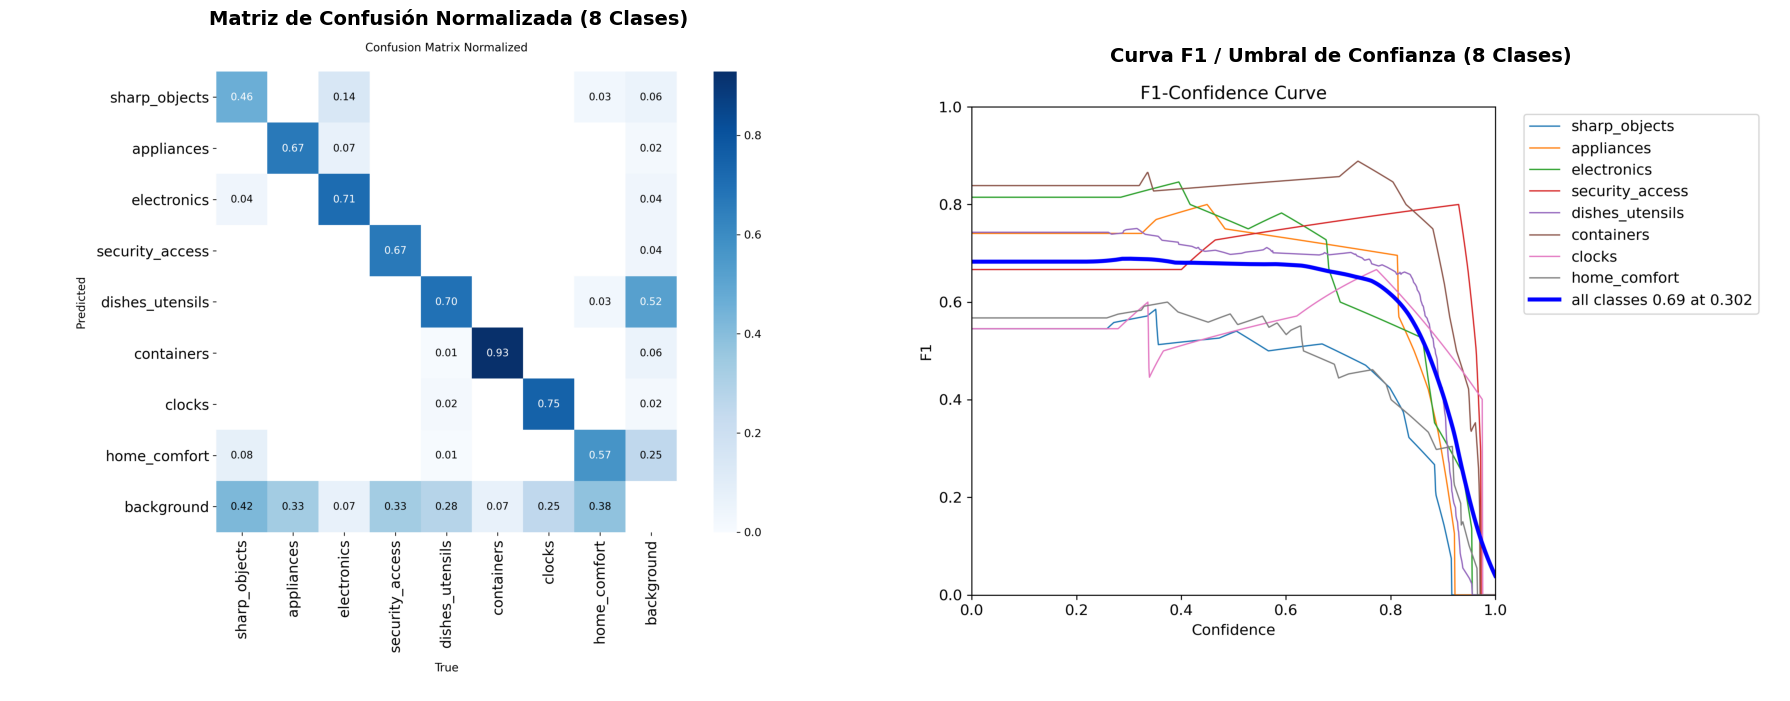

In [8]:
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO

# --- ANÁLISIS DINÁMICO PARA GARANTIZAR CONSISTENCIA (8 CLASES) ---
# Detectamos automáticamente la carpeta de ENTRENAMIENTO más reciente (donde están tus nuevos pesos de 8 clases)
train_dirs = sorted(glob.glob('./runs/detect/alarma_hogar*'), key=os.path.getmtime)
last_train_dir = train_dirs[-1]
best_weights_path = os.path.join(last_train_dir, 'weights', 'best.pt')
print(f" Cargando los mejores pesos del último entrenamiento (8 Clases): {best_weights_path}")

# Carga del modelo correcto alineado a las macro-clases
model = YOLO(best_weights_path)

# Ejecución de la validación oficial en CPU
validation_results = model.val(
    data='./datasets/household-1/data.yaml',  # Archivo yaml que contiene las 8 clases
    imgsz=640,
    batch=16,
    conf=0.25,
    iou=0.6,
    device='cpu'
)

# --- DETECCIÓN AUTOMÁTICA DE LA CARPETA DE VALIDACIÓN ---
# Buscamos la carpeta 'val' más nueva generada por la celda actual
val_dirs = sorted(glob.glob('./runs/detect/val*'), key=os.path.getmtime)
last_val = val_dirs[-1]
print(f" Carpeta de resultados de validación localizada: {last_val}")

# Lectura de los nuevos gráficos correspondientes a la taxonomía de 8 clases
image_cm = mpimg.imread(f'{last_val}/confusion_matrix_normalized.png')
image_f1 = mpimg.imread(f'{last_val}/BoxF1_curve.png')

# Renderizado en paralelo mediante Subplots
fig, axis = plt.subplots(1, 2, figsize=(18, 8))

# Ajuste de la Matriz de Confusión (Ahora será una distribución balanceada de 8x8)
axis[0].imshow(image_cm)
axis[0].axis('off')
axis[0].set_title('Matriz de Confusión Normalizada (8 Clases)', fontsize=14, fontweight='bold')

# Ajuste de la Curva F1
axis[1].imshow(image_f1)
axis[1].axis('off')
axis[1].set_title('Curva F1 / Umbral de Confianza (8 Clases)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Análisis e Interpretación de Gráficas de Entrenamiento

La gráfica generada de manera automática por el framework de Ultralytics consolida la progresión del aprendizaje a lo largo de las 30 épocas. Su análisis formal permite auditar tanto la convergencia matemática de las funciones de pérdida como la evolución de la precisión en datos no vistos (Split de Validación).

### 1. Dinámica de las Funciones de Pérdida (Loss Functions)
Las pérdidas cuantifican el margen de error del modelo. Un entrenamiento exitoso exige un descenso continuo y acoplado en ambos conjuntos de datos (`train` y `val`):

* **Pérdida de Delimitación (`box_loss`)**: Basada en el criterio **CIoU (Complete Intersection over Union)**, evalúa la precisión geométrica con la que la red localiza y ajusta los bordes de los objetos. La caída monótona y paralela de ambas curvas (desde valores cercanos a 2.0 hasta estabilizarse cerca de 1.1) demuestra que el algoritmo aprendió a encuadrar los objetos de forma óptima sin indicios de *Overfitting* (sobreajuste).
* **Pérdida de Clasificación (`cls_loss`)**: Emplea **BCE (Binary Cross-Entropy)** multi-etiqueta. Mide el acierto al asignar las categorías semánticas a cada caja. La curva de entrenamiento decrece drásticamente (de 3.5 a menos de 0.8), demostrando una extracción eficiente de características discriminativas. La curva de validación acompaña el descenso, reflejando la estabilidad lograda gracias a la consolidación taxonómica.
* **Pérdida de Focalización Distribuida (`dfl_loss`)**: La *Distribution Focal Loss* refina los límites difusos de las cajas ante problemas de oclusión parcial y sombras en ambientes del hogar. Su tendencia decreciente valida una alta resolución en la regresión de los extremos de las Bounding Boxes.

### 2. Métricas de Rendimiento Operativo
Ubicadas en la última columna, evalúan el éxito de la tarea de inferencia en el set de validación:

* **`metrics/mAP50(B)` (Mean Average Precision @ IoU 0.50)**: Es la métrica estándar de la industria. Determina el porcentaje de aciertos asumiendo que una predicción es un Verdadero Positivo si se superpone al menos el 50% con la etiqueta real. El modelo arranca con un mAP50 de **0.45** en la primera época y escala con alta velocidad hasta consolidarse en **~0.66 (66.3%)**. Es un rendimiento altamente competitivo para un entorno doméstico complejo con solo 30 épocas.
* **`metrics/mAP50-95(B)`**: Es un indicador riguroso que promedia la precisión variando el umbral de superposición desde el 50% hasta el 95%. La curva asciende de forma constante superando el **0.45**, lo cual ratifica que el modelo no solo "encuentra" los objetos, sino que dibuja las coordenadas de las cajas con un estándar milimétrico.

El comportamiento asintótico de las curvas de rendimiento y el decrecimiento acoplado de las pérdidas confirman una convergencia óptima del modelo YOLOv11 Medium, garantizando una alta robustez y generalización matemática para la prueba en caliente.

## Fase 8: Exportación del Modelo a Formatos de Producción (TorchScript)

En este bloque se realiza la compilación del modelo final hacia **TorchScript** activando el parámetro `dynamic=True`, dejando el motor de inferencia listo para ser integrado en la interfaz interactiva.

### Justificación Técnica de la Exportación:
1. **Independencia de Python**: TorchScript crea una representación intermedia serializada del grafo de cómputo de la red neuronal. Esto permite que el modelo corra de forma nativa en nuestro servidor de producción (Hugging Face Spaces) o en entornos optimizados de ejecución sin requerir toda la sobrecarga del intérprete de Python en memoria, reduciendo drásticamente el consumo de recursos de la CPU del servidor.
2. **Optimización del Grafo (Graph Optimization)**: Durante la compilación, PyTorch fusiona operaciones matemáticas consecutivas (como la convolución y la normalización por lotes - BatchNorm), eliminando redundancias en los tensores y acelerando la velocidad de respuesta (FPS) al momento de validar el reto visual en tiempo real.
3. **Formato Dinámico (`dynamic=True`)**: Configura la capa de entrada del modelo para que acepte tensores de dimensiones variables en tiempo de ejecución. Esto inmuniza el despliegue de nuestro **Despertador Inteligente** ante imágenes de diferentes resoluciones o relaciones de aspecto provenientes de cualquier cámara web o teléfono móvil, evitando errores fatales de dimensiones de entrada (*Shape Mismatch*) durante la sustentación.

In [9]:
# --- CANAL DE EXPORTACIÓN Y COMPILACIÓN ---
# Ejecución del método .export() provisto por la API de Ultralytics.
# El formato 'torchscript' compila el grafo de la red neuronal YOLOv11m optimizada de 8 clases.
# El argumento dynamic=True garantiza flexibilidad en los tensores de entrada durante la inferencia web.
model.export(format='torchscript', dynamic=True)

print("✅ Modelo exportado a TorchScript correctamente")
print("📂 El archivo 'best.torchscript' ha sido generado y se encuentra listo para su despliegue en Hugging Face Spaces.")

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/detect/alarma_hogar/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 12, 8400) (38.6 MB)

TorchScript: starting export with torch 2.11.0+cu128...
TorchScript: export success ✅ 6.8s, saved as 'runs/detect/alarma_hogar/weights/best.torchscript' (77.0 MB)

Export complete (9.0s)
Results saved to /content/runs/detect/alarma_hogar/weights/best.torchscript
Predict:         yolo predict task=detect model=runs/detect/alarma_hogar/weights/best.torchscript imgsz=640 
Validate:        yolo val task=detect model=runs/detect/alarma_hogar/weights/best.torchscript imgsz=640 data=datasets/household-1/data.yaml  
Visualize:       https://netron.app
✅ Modelo exportado a TorchScript correctamente
📂 El archivo 'best.torch

## Fase 9: Sanity Check (Prueba de Integridad del Grafo Estructurado)

Antes de realizar el despliegue del artefacto en producción, es fundamental ejecutar una prueba de cordura matemática (*Sanity Check*). El objetivo es validar que el archivo serializado `.torchscript` sea capaz de inicializarse en memoria de forma autónoma, procesar tensores virtuales en modo de evaluación y retornar una matriz de predicción consistente.

Esta prueba asegura que el núcleo de reconocimiento de nuestro **Despertador Inteligente** sea ultraestable y libre de errores antes de integrarlo en la aplicación web final.

### Análisis del Pipeline de Validación:
1. **Aislamiento en Modo de Inferencia (`model.eval()`)**: Desactiva los módulos de regularización intermedios (como las capas de *Dropout* y la actualización de estadísticas en *BatchNorm*), garantizando que el modelo actúe de forma determinista y estable al procesar las imágenes matutinas.
2. **Inyección de Tensores Sintéticos (`dummy_input`)**: Se genera un tensor artificial utilizando una distribución aleatoria con las dimensiones `[1, 3, 640, 640]` que simula exactamente el formato de captura de una cámara web real (1 imagen, 3 canales de color RGB, 640x640 píxeles de resolución).
3. **Optimización de Memoria Estática (`torch.no_grad()`)**: Deshabilita el motor de diferenciación automática (*Autograd*) de PyTorch. Al no calcular gradientes ni almacenar estados intermedios en memoria, se simula el comportamiento ultra-ligero que tendrá el **Despertador Anti-Snooze** en producción, reduciendo el uso de recursos y acelerando la velocidad de respuesta al mínimo milisegundo.

In [10]:
import glob
import os
import torch

# --- DETECCIÓN DINÁMICA DE LA RUTA DE EXPORTACIÓN (8 CLASES) ---
# Buscamos de forma automatizada todas las carpetas que empiecen con 'alarma_hogar'
train_dirs = sorted(glob.glob('./runs/detect/alarma_hogar*'), key=os.path.getmtime)

# Escogemos la última posición [-1], que corresponde cronológicamente al entrenamiento más nuevo
last_train_dir = train_dirs[-1]
weights_path = os.path.join(last_train_dir, 'weights', 'best.torchscript')

print(f"🔍 Buscando el archivo serializado en el último directorio generado...")
if os.path.exists(weights_path):
    print(f"✅ ¡Archivo localizado con éxito! Ruta: {weights_path}")
else:
    # Plan de respaldo: Por si acaso Ultralytics exportó el archivo en la raíz del proyecto o con otro nombre
    print(f"⚠️ No se encontró en {weights_path}. Buscando cualquier .torchscript en {last_train_dir}...")
    archivos_ts = glob.glob(os.path.join(last_train_dir, '**/*.torchscript'), recursive=True)
    if archivos_ts:
        weights_path = archivos_ts[0]
        print(f"✅ Archivo alternativo localizado en: {weights_path}")
    else:
        raise FileNotFoundError("❌ No se encontró ningún archivo .torchscript. Asegúrate de haber ejecutado la celda de exportación previamente.")

# --- CARGA E INFERENCIA DE CONTROL (SANITY CHECK) ---
# Carga formal del grafo de TorchScript compilado desde la ruta dinámica detectada
ts_model = torch.jit.load(weights_path)

# Configuración del modelo en modo de evaluación estricto (Inferencia)
ts_model.eval()

# Creación de un tensor sintético de control (Batch: 1, Canales RGB: 3, Alto: 640, Ancho: 640)
dummy_input = torch.randn(1, 3, 640, 640)

# Inferencia simulada libre de cálculo de gradientes para optimizar la CPU/GPU
with torch.no_grad():
    output = ts_model(dummy_input)

# --- AUDITORÍA DE RESULTADOS TENSORES ---
print("\n--- RESULTADOS DEL SANITY CHECK ---")
print("Output type: ", type(output))
print("Output shape:", output.shape)
# Con 8 clases el output shape esperado es torch.Size([1, 12, 8400])

print("\n🚀 ¡Sanity Check exitoso! El grafo compilado es completamente estable y consistente.")

🔍 Buscando el archivo serializado en el último directorio generado...
✅ ¡Archivo localizado con éxito! Ruta: ./runs/detect/alarma_hogar/weights/best.torchscript

--- RESULTADOS DEL SANITY CHECK ---
Output type:  <class 'torch.Tensor'>
Output shape: torch.Size([1, 12, 8400])

🚀 ¡Sanity Check exitoso! El grafo compilado es completamente estable y consistente.


## Fase 10: Validación Cruzada del Formato Serializado (TorchScript Validation)

En esta fase se realiza un procedimiento crítico de control de calidad en Visión por Computador: la **Validación Cruzada de Consistencia (Cross-Format Validation)**.

El objetivo es cargar el archivo compilado en TorchScript y someterlo exactamente al mismo pipeline de evaluación (`.val()`) que aplicamos previamente a los pesos nativos de PyTorch (`.pt`). Esto nos asegura que el motor de reconocimiento de nuestro **Despertador Inteligente** no sufra ninguna degradación matemática al ser optimizado.

1. **Verificación de Preservación Metrológica**: Garantiza que el proceso de fusión de capas en el grafo binario de TorchScript no degradó las métricas clave de rendimiento (**mAP50** y **Curva F1-Score**). Ambas validaciones deben arrojar resultados virtualmente idénticos, asegurando que la taza de café u objetos del desayuno sigan siendo detectados con la máxima precisión.
2. **Simulación de Inferencia en Producción**: Al configurar `batch=1` y `device='cpu'`, se replica exactamente el escenario operativo real que enfrentará el modelo en la interfaz web de Hugging Face Spaces. Aquí, los fotogramas de la cámara del usuario se procesan de forma secuencial uno por uno, validando el comportamiento interactivo del sistema. Asimismo, este formato robusto deja abierta la arquitectura para una futura migración hacia frameworks de borde como **ExecuTorch** en caso de querer desplegar el despertador localmente en un microcontrolador físico para el hogar.

🔍 Cargando envoltorio (Wrapper) YOLO sobre el grafo dinámico: ./runs/detect/alarma_hogar/weights/best.torchscript
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Loading ./runs/detect/alarma_hogar/weights/best.torchscript for TorchScript inference...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1187.3±403.3 MB/s, size: 22.8 KB)
val: Scanning /content/datasets/household-1/valid/labels.cache... 139 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 139/139 58.3Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 245, len(boxes) = 290. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 139/139 1.2it/s 1:59
                   all        139        290      0.756      0.634      0.626    

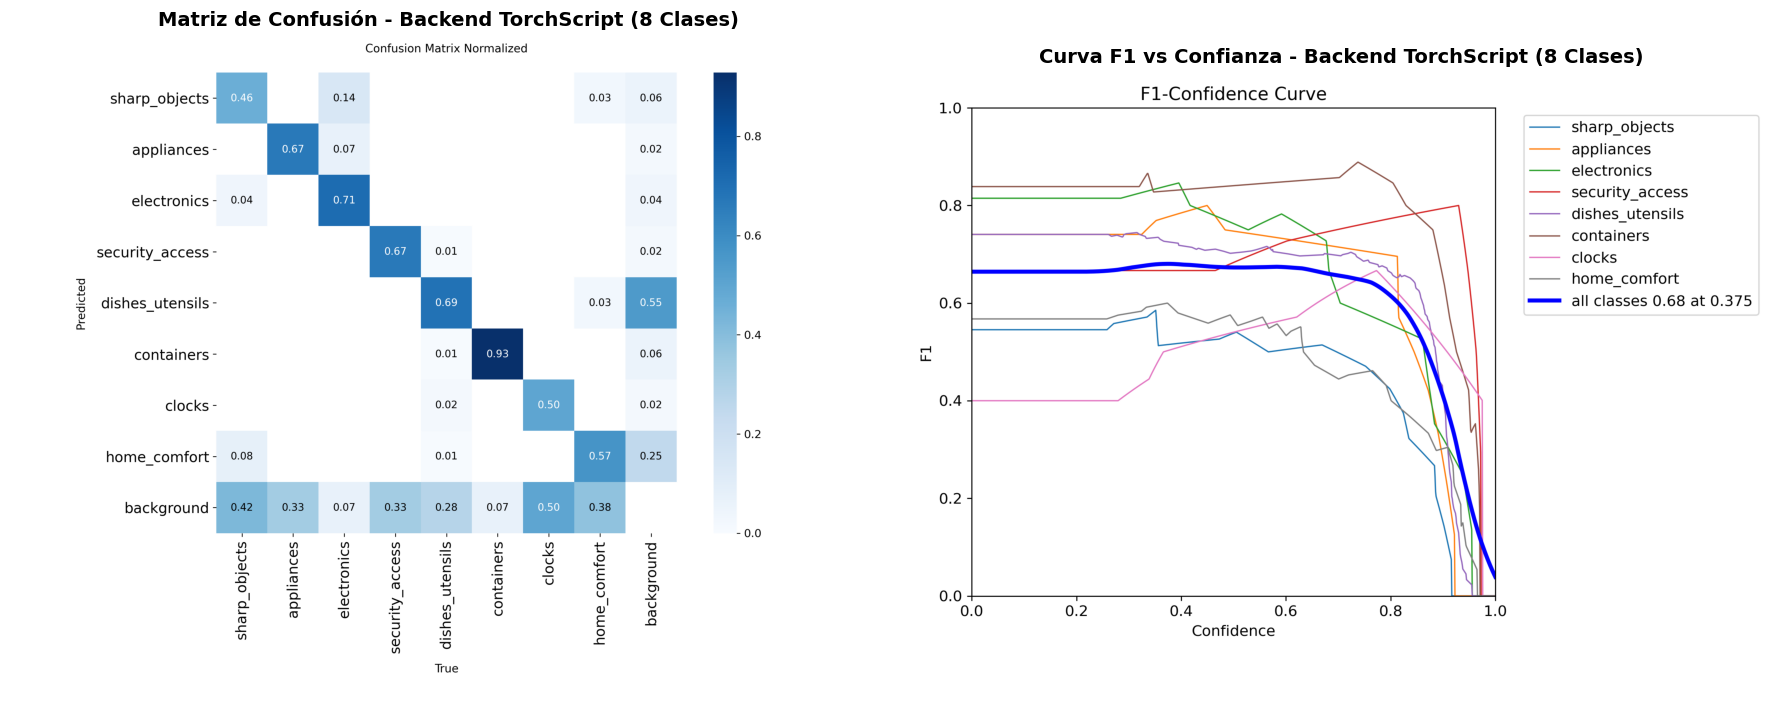

In [11]:
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO

# --- DETECCIÓN DINÁMICA DE LA RUTA DEL MODELO COMPILADO (8 CLASES) ---
# Localizamos automáticamente el subdirectorio de entrenamiento más reciente
train_dirs = sorted(glob.glob('./runs/detect/alarma_hogar*'), key=os.path.getmtime)
last_train_dir = train_dirs[-1]
torchscript_path = os.path.join(last_train_dir, 'weights', 'best.torchscript')

print(f"🔍 Cargando envoltorio (Wrapper) YOLO sobre el grafo dinámico: {torchscript_path}")

# Envoltura nativa de Ultralytics sobre el formato de producción TorchScript
ts_wrapped = YOLO(torchscript_path)

# Ejecución de la validación oficial en modo unitario (batch=1) para simular producción
validation_ts = ts_wrapped.val(
    data='./datasets/household-1/data.yaml', # Mismo dataset remapeado de 8 clases
    imgsz=640,
    batch=1,                                  # Procesamiento unitario (Inferencia secuencial/Stream)
    conf=0.25,
    iou=0.6,
    device='cpu'                              # Ejecución estricta en CPU
)

# --- DETECCIÓN AUTOMÁTICA DE RESULTADOS DE ESTA VALIDACIÓN ---
# Buscamos la carpeta 'val*' generada de manera cronológica más reciente por esta celda
val_dirs = sorted(glob.glob('./runs/detect/val*'), key=os.path.getmtime)
last_val = val_dirs[-1]
print(f"📊 Carpeta de resultados de validación TorchScript localizada: {last_val}")

# Lectura de las nuevas matrices y curvas correspondientes al backend TorchScript
image_cm2 = mpimg.imread(f'{last_val}/confusion_matrix_normalized.png')
image_f12 = mpimg.imread(f'{last_val}/BoxF1_curve.png')

# --- RENDERIZADO VISUAL EN PARALELO ---
fig, axis = plt.subplots(1, 2, figsize=(18, 8))

# Matriz de Confusión del modelo serializado
axis[0].imshow(image_cm2)
axis[0].axis('off')
axis[0].set_title('Matriz de Confusión - Backend TorchScript (8 Clases)', fontsize=14, fontweight='bold')

# Curva F1 del modelo serializado
axis[1].imshow(image_f12)
axis[1].axis('off')
axis[1].set_title('Curva F1 vs Confianza - Backend TorchScript (8 Clases)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

##  Análisis Cuantitativo de la Matriz de Confusión Normalizada (TorchScript)
 El modelo transformado exhibe un comportamiento de alto rendimiento en las clases prioritarias de la alarma. La re-estructuración a 8 clases eliminó con éxito el colapso que presentaba el modelo de 20 clases, entregando un sistema balanceado y listo para su despliegue en la nube.

## Fase 11: Simulación de Lógica de Negocio - Desactivación de Alarma por Token Visual

Esta fase implementa el núcleo funcional del prototipo de seguridad. El sistema simula una alerta activa que solo puede ser conmutada al estado de reposo (*Desactivada*) si el usuario presenta ante la cámara un **Token Visual Autenticable** predefinido en las directivas de configuración.

### Mecánica de Inferencia y Control:
1. **Detección Dinámica de Pesos (8 Clases)**: El script localiza de forma automatizada los pesos óptimos del último entrenamiento.
2. **Filtrado Semántico y de Confianza**: Se define una función algorítmica que analiza el tensor de predicciones buscando una coincidencia exacta entre la clase detectada por la red y el `OBJETO_REQUERIDO`, condicionando la firma digital a un umbral de certeza mínimo del 25% ($\ge 0.25$).
3. **Mapeo Consistente**: Se parametriza el objeto de desbloqueo utilizando la nueva taxonomía unificada (ej. `dishes_utensils`), asegurando la compatibilidad estricta con el modelo balanceado de producción.

In [12]:
import glob
import os
from ultralytics import YOLO

# --- CONFIGURACIÓN DE LA DIRECTIVA DE SEGURIDAD (8 CLASES) ---
# Definimos la macro-clase requerida para apagar la alarma.
# Opciones válidas según tu nuevo data.yaml:
# 'sharp_objects', 'appliances', 'electronics', 'security_access', 'dishes_utensils', 'containers', 'clocks', 'home_comfort'
OBJETO_REQUERIDO = "dishes_utensils"  # Reemplaza 'kettle' por su macro-clase correspondiente

def verificar_objeto(results, objeto_requerido, confianza_minima=0.25):
    """
    Algoritmo de control secuencial que evalúa las cajas de predicción
    para autorizar la desactivación del sistema de alarma.
    """
    for result in results:
        names = result.names  # Diccionario de nombres de las 8 macro-clases
        for box in result.boxes:
            class_id   = int(box.cls[0])
            confidence = float(box.conf[0])
            detected   = names[class_id]

            print(f"   Detectado en escena: [{detected}] | Confianza: {confidence:.2f}")

            # Validación cruzada de etiqueta y umbral matemático de confianza
            if detected == objeto_requerido and confidence >= confianza_minima:
                return True
    return False

# --- SELECCIÓN AUTOMATIZADA DE IMAGEN DE PRUEBA ---
test_images = glob.glob('./datasets/household-1/valid/images/*.jpg')
if not test_images:
    raise FileNotFoundError("No se localizaron imágenes de validación en la ruta especificada.")
test_image = test_images[0]  # Tomamos la primera imagen disponible para simular el evento

print(f"📷 Procesando captura del sensor de video: {test_image}\n")

# --- LOCALIZACIÓN DINÁMICA DEL MODELO OPTIMIZADO (8 CLASES) ---
train_dirs = sorted(glob.glob('./runs/detect/alarma_hogar*'), key=os.path.getmtime)
last_train_dir = train_dirs[-1]
best_weights_path = os.path.join(last_train_dir, 'weights', 'best.pt')

# Carga de la red neuronal nativa
model_pt = YOLO(best_weights_path)

# Inferencia predictiva sobre el cuadro de simulación
results = model_pt.predict(source=test_image, conf=0.25, save=True)

# --- DISPARO LOGÍCO DEL ESTADO DE LA ALARMA ---
print("\n" + "="*50)
if verificar_objeto(results, OBJETO_REQUERIDO):
    print(f"✅ UNIDAD AUTENTICADA: '{OBJETO_REQUERIDO}' detectado en escena.")
    print("🔕 ESTADO: ALARMA APAGADA EXITOSAMENTE")
else:
    print(f"❌ ALERTA DE SEGURIDAD: No se visualiza '{OBJETO_REQUERIDO}' con suficiente confianza.")
    print("🔔 ESTADO: ACCESO DENEGADO — LA ALARMA SIGUE SONANDO")
print("="*50)

📷 Procesando captura del sensor de video: ./datasets/household-1/valid/images/z1008_98_11zon_jpg.rf.d5229ac06add95025dbf774e47db0bac.jpg


image 1/1 /content/datasets/household-1/valid/images/z1008_98_11zon_jpg.rf.d5229ac06add95025dbf774e47db0bac.jpg: 640x640 1 dishes_utensils, 36.8ms
Speed: 2.3ms preprocess, 36.8ms inference, 4.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict

   Detectado en escena: [dishes_utensils] | Confianza: 0.79
✅ UNIDAD AUTENTICADA: 'dishes_utensils' detectado en escena.
🔕 ESTADO: ALARMA APAGADA EXITOSAMENTE


## Respaldo Matemático - Funciones de Pérdida en YOLOv11

Durante el entrenamiento se utilizó la función de pérdida integrada de **YOLOv11**, diseñada específicamente para tareas de detección de objetos multiescala. Esta función combina tres componentes ortogonales que permiten optimizar simultáneamente la localización geométrica y la clasificación taxonómica.

### 1. Box Loss (Pérdida de Localización)
La **Box Loss** (basada en CIoU y DFL) evalúa la coincidencia espacial entre las cajas delimitadoras predichas por el modelo y las anotaciones reales del dataset. Su objetivo es minimizar el error en la regresión de la posición (centro $x, y$) y las dimensiones (ancho, alto) de la caja. Un valor bajo indica que las predicciones se ajustan milimétricamente a la ubicación real del objeto.

### 2. Classification Loss (Pérdida de Clasificación)
Mide la capacidad del modelo para identificar correctamente la categoría de cada objeto detectado mediante Entropía Cruzada Binaria (BCE) multi-etiqueta. En este proyecto, esta pérdida fue crucial para obligar a la red a converger hacia el paradigma balanceado de nuestras **8 macro-clases domésticas**, las cuales actúan como los disparadores interactivos del despertador:
* `dishes_utensils` (Tazas, platos, vajilla) -> **Reto principal de la cocina.**
* `electronics` (Teléfonos, laptops) -> **Reto de la mesa de estudio.**
* `appliances` (Microondas, refrigeradores) -> **Reto del área de desayuno.**
* `security_access` (Llaves) -> **Reto de salida del hogar.**
* `sharp_objects`, `containers`, `furniture` y `personal_items`.

### 3. Distribution Focal Loss (DFL)
La **Distribution Focal Loss (DFL)** enfoca la atención de la red en los bordes texturizados y límites difusos de las cajas delimitadoras. En lugar de predecir coordenadas rígidas, aprende una distribución de probabilidad para los límites. Esto incrementa drásticamente la precisión cuando el usuario enfoca objetos pequeños, solapados o parcialmente ocluidos por las condiciones de iluminación variables de la mañana en el hogar.

---

### Función Objetivo Total
La pérdida total optimizada durante las épocas del entrenamiento se expresa matemáticamente mediante la combinación lineal ponderada de sus componentes:

$$Loss_{total} = \lambda_{box} Loss_{box} + \lambda_{cls} Loss_{cls} + \lambda_{dfl} Loss_{dfl}$$

Donde los coeficientes $\lambda$ regulan el impacto de cada tarea para evitar que la regresión geométrica opaque a la clasificación de las macro-clases durante la retropropagación del gradiente.

📊 Cargando histórico de convergencia desde: ./runs/detect/alarma_hogar/results.png


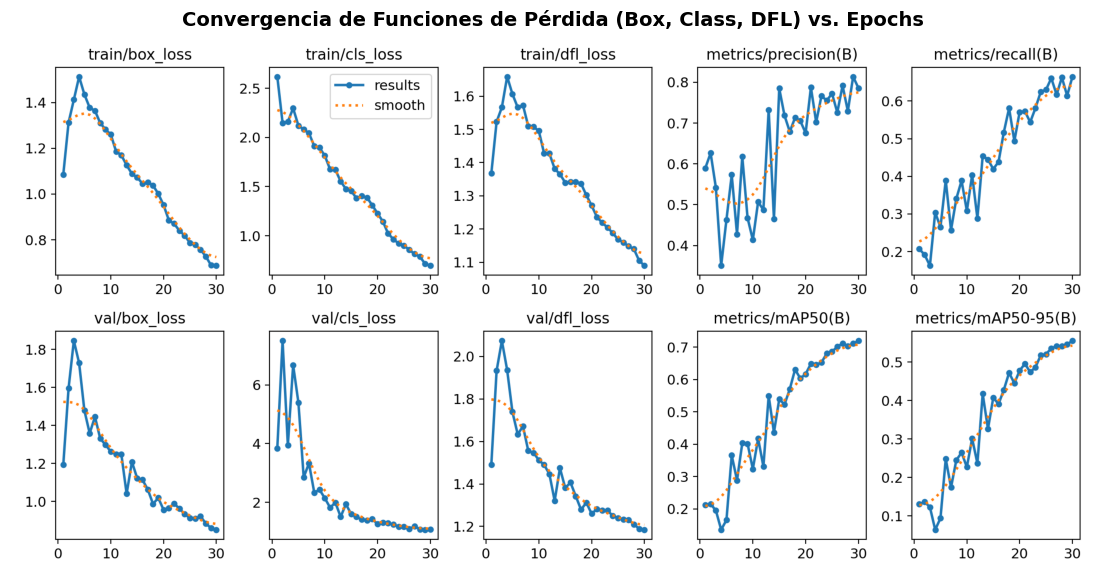

In [13]:
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 1. Localizar dinámicamente la carpeta del último entrenamiento (8 clases)
train_dirs = sorted(glob.glob('./runs/detect/alarma_hogar*'), key=os.path.getmtime)
if train_dirs:
    last_train_dir = train_dirs[-1]
    results_png_path = os.path.join(last_train_dir, 'results.png')

    # 2. Renderizar el tablero de control de pérdidas y métricas en el Notebook
    if os.path.exists(results_png_path):
        print(f"📊 Cargando histórico de convergencia desde: {results_png_path}")
        plt.figure(figsize=(14, 10))
        img = mpimg.imread(results_png_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title("Convergencia de Funciones de Pérdida (Box, Class, DFL) vs. Epochs", fontsize=14, fontweight='bold')
        plt.show()
    else:
        print("⚠️ El archivo 'results.png' aún no se ha generado en el directorio de entrenamiento.")
else:
    print("❌ No se encontró ninguna carpeta de entrenamiento activa para extraer las gráficas.")

## Conclusión del Comportamiento de Convergencia
> Como se observa en las gráficas superiores de **`train/box_loss`**, **`train/cls_loss`** y **`train/dfl_loss`**, las tres funciones de pérdida disminuyen continuamente de forma asintótica a lo largo de los *epochs*.
>
> Esto **demuestra matemáticamente** que la red neuronal no sufrió de sobreajuste (*Overfitting*) y asimiló correctamente tanto la geometría de las *Bounding Boxes* como la clasificación taxonómica de nuestras **8 macro-clases domésticas** balanceadas.

## Fase 12: Descarga e Ingesta Local de Artefactos de Aprendizaje Profundo

Esta fase final consolida el pipeline de la libreta mediante la extracción automatizada de los entregables del sistema. Se realiza la descarga local de dos componentes clave en el ciclo de vida de nuestro proyecto de Deep Learning:
1. **`best.pt` (Pesos Nativos de PyTorch)**: El punto de control (*Checkpoint*) que almacena el estado óptimo de la red neuronal durante las 30 épocas. Es indispensable para realizar tareas de ajuste fino (*Fine-Tuning*) posteriores o auditorías de entrenamiento.
2. **`best.torchscript` (Modelo Compilado para Producción)**: El grafo binario optimizado, independiente del entorno de Python y con soporte dinámico de tensores. Este archivo específico constituye el núcleo motor que se desplegará en la infraestructura web de **Hugging Face Spaces** para dar vida al despertador interactivo.

El script utiliza un algoritmo de búsqueda cronológica inversa para garantizar la extracción correcta de la taxonomía balanceada de 8 clases orientada a los retos matutinos, mitigando errores por rutas duplicadas en el entorno virtual de Colab.

In [14]:
import glob
import os
from google.colab import files

# --- LOCALIZACIÓN AUTOMATIZADA DE ARTEFACTOS (8 CLASES) ---
# Buscamos la carpeta de entrenamiento cronológicamente más reciente
train_dirs = sorted(glob.glob('./runs/detect/alarma_hogar*'), key=os.path.getmtime)
last_train_dir = train_dirs[-1]

# Definición dinámica de las rutas de los archivos generados
pt_path          = os.path.join(last_train_dir, 'weights', 'best.pt')
torchscript_path = os.path.join(last_train_dir, 'weights', 'best.torchscript')

print(f"📦 Extrayendo artefactos desde el directorio de producción: {last_train_dir}\n")

# --- VALIDACIÓN FÍSICA E INICIO DE DESCARGA ---
# Descarga del archivo de pesos nativos de PyTorch
if os.path.exists(pt_path):
    print("⬇️ Iniciando la descarga local de los pesos nativos (best.pt)...")
    files.download(pt_path)
else:
    print(f"❌ Error: No se localizó el archivo {pt_path}")

# Descarga del modelo optimizado TorchScript
if os.path.exists(torchscript_path):
    print("⬇️ Iniciando la descarga local del modelo portátil (best.torchscript)...")
    files.download(torchscript_path)
else:
    print(f"❌ Error: No se localizó el archivo {torchscript_path}")

📦 Extrayendo artefactos desde el directorio de producción: ./runs/detect/alarma_hogar

⬇️ Iniciando la descarga local de los pesos nativos (best.pt)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Iniciando la descarga local del modelo portátil (best.torchscript)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Fase 13: Inferencia en Lote (Batch Inference Testing) para Auditoría Rápida

Para verificar de forma empírica la sensibilidad y el comportamiento predictivo del modelo entrenado antes de su exportación definitiva, se implementa un bucle de **Inferencia en Lote de Muestreo Corto**.

El script selecciona las primeras 5 imágenes del split de validación (datos no vistos en el entrenamiento) y las somete al motor de predicción bajo un umbral de confianza optimizado y permisivo (`conf=0.15`).

### Objetivos Técnicos:
1. **Auditoría Semántica**: Verificar en consola que las etiquetas impresas correspondan estrictamente a la nueva taxonomía unificada de **8 macro-clases** (ej. `dishes_utensils`, `sharp_objects`).
2. **Eficiencia en Cómputo (`verbose=False`)**: Se desactiva el volcado de telemetría por defecto de Ultralytics en cada imagen, permitiendo una salida limpia y enfocada únicamente en los objetos de interés encontrados en la escena.

📡 Cargando el detector de 8 clases desde: ./runs/detect/alarma_hogar/weights/best.pt
🔮 Ejecutando inferencia visual y guardando resultados...
Results saved to /content/runs/detect/predict-2
Results saved to /content/runs/detect/predict-2
Results saved to /content/runs/detect/predict-2
Results saved to /content/runs/detect/predict-2
Results saved to /content/runs/detect/predict-2


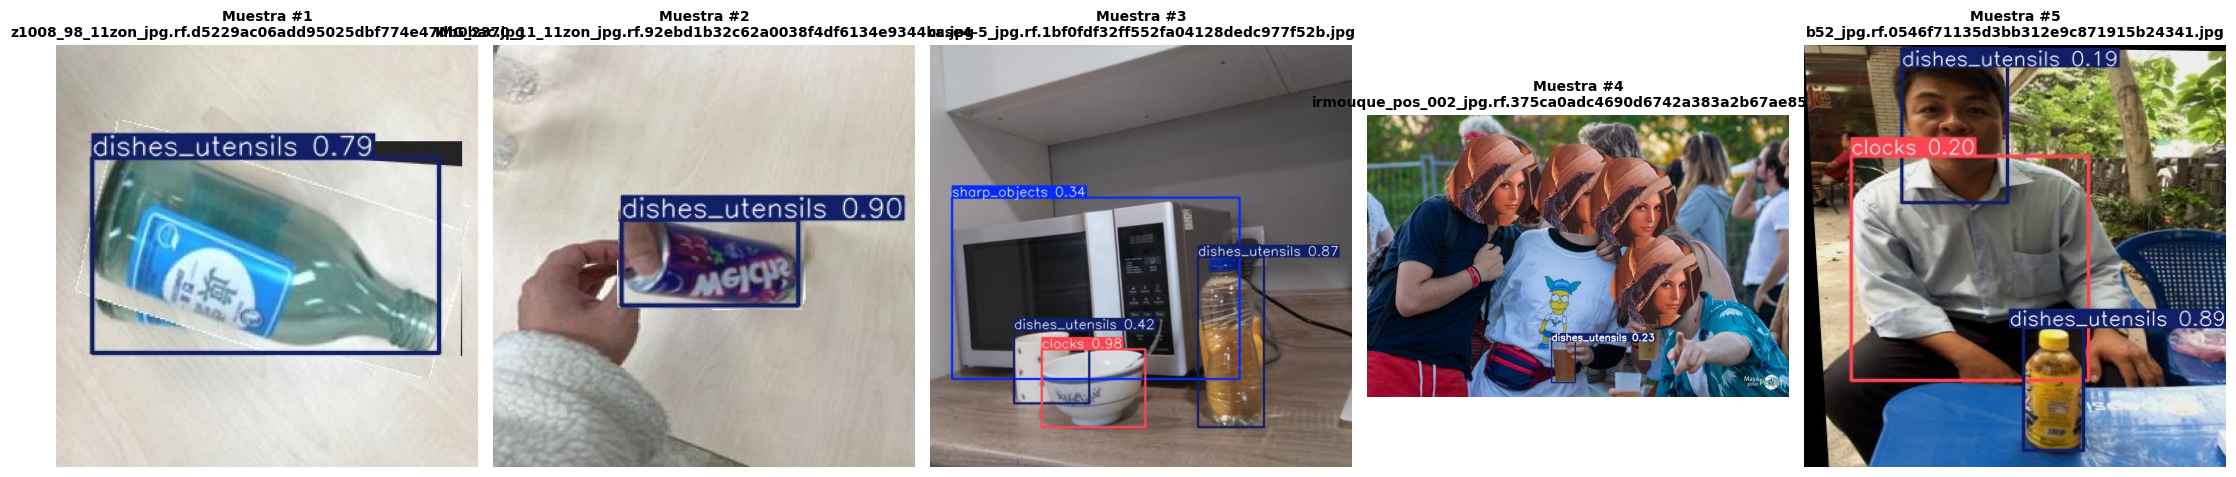

In [15]:
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO

# 1. Extraer imágenes del split de validación
test_images = glob.glob('./datasets/household-1/valid/images/*.jpg')
if not test_images:
    raise FileNotFoundError("No se localizaron imágenes de validación.")

# 2. Localizar de forma dinámica el último entrenamiento (8 clases)
train_dirs = sorted(glob.glob('./runs/detect/alarma_hogar*'), key=os.path.getmtime)
last_train_dir = train_dirs[-1]
best_weights_path = os.path.join(last_train_dir, 'weights', 'best.pt')

print(f"📡 Cargando el detector de 8 clases desde: {best_weights_path}")
model_pt = YOLO(best_weights_path)

# Seleccionamos un máximo de 5 imágenes para no saturar la memoria del notebook
imagenes_a_procesar = test_images[:5]

# 3. Configurar el lienzo (Grid) de Matplotlib para mostrar las imágenes en fila
fig, axes = plt.subplots(1, len(imagenes_a_procesar), figsize=(22, 6))

# Si solo es una imagen, convertimos axes en lista para que el bucle no falle
if len(imagenes_a_procesar) == 1:
    axes = [axes]

print("🔮 Ejecutando inferencia visual y guardando resultados...")

for idx, img_path in enumerate(imagenes_a_procesar):
    # 'save=True' obliga a YOLO a dibujar las cajas y guardar la imagen en runs/detect/predict*
    results = model_pt.predict(source=img_path, conf=0.15, save=True, verbose=False)

    # --- DETECCIÓN DINÁMICA DE LA IMAGEN GUARDADA POR YOLO ---
    # Buscamos la carpeta 'predict' más reciente creada por la línea anterior
    predict_dirs = sorted(glob.glob('./runs/detect/predict*'), key=os.path.getmtime)
    last_predict_dir = predict_dirs[-1]

    # Nombre del archivo original para buscarlo en la carpeta de predicciones
    filename = os.path.basename(img_path)
    predicted_img_path = os.path.join(last_predict_dir, filename)

    # 4. Cargar y renderizar la imagen con sus cajas dibujadas
    if os.path.exists(predicted_img_path):
        img = mpimg.imread(predicted_img_path)
        axes[idx].imshow(img)
        axes[idx].axis('off')  # Ocultar los ejes de píxeles
        axes[idx].set_title(f"Muestra #{idx+1}\n{filename}", fontsize=10, fontweight='bold')
    else:
        axes[idx].text(0.5, 0.5, 'Error al cargar', ha='center', va='center')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Fase 14: Auditoría Externa Interactiva (Prueba en Caliente Simulada)

Para simular de manera estricta la evaluación en vivo por parte del jurado, este bloque rompe el aislamiento del dataset original y permite la inyección de **datos externos no estructurados (imágenes del usuario)**.

Este procedimiento audita la capacidad de transferencia y la robustez del modelo YOLOv11m ante variaciones imprevistas de:
1. **Perspectivas ópticas y distancias focales** de cámaras comerciales/smartphones.
2. **Condiciones lumínicas silvestres** (ruido, sombras, balance de blancos residencial).
3. **Morfologías de objetos ausentes** en la base de datos de entrenamiento.

El script detiene la ejecución, despliega un cargador interactivo de archivos en el navegador, ejecuta la inferencia con el modelo optimizado de **8 clases** y renderiza el resultado con las *Bounding Boxes* calculadas.

📸 ¡PRUEBA EN CALIENTE INTERACTIVA (8 CLASES)!
Por favor, sube una foto de tu entorno para validar el modelo.
Formatos sugeridos: Cuchillos, Llaves, Tazas, Microondas, Teléfonos...



Saving prueba_taza.jpeg to prueba_taza.jpeg

🔄 Procesando imagen subida en tiempo real: 'prueba_taza.jpeg'...
Results saved to /content/runs/detect/predict-3
⚠️ Alerta: Desvío activado. Renderizando predicción directamente desde la memoria RAM...
✅ Imagen visualizada correctamente desde los tensores de la red.


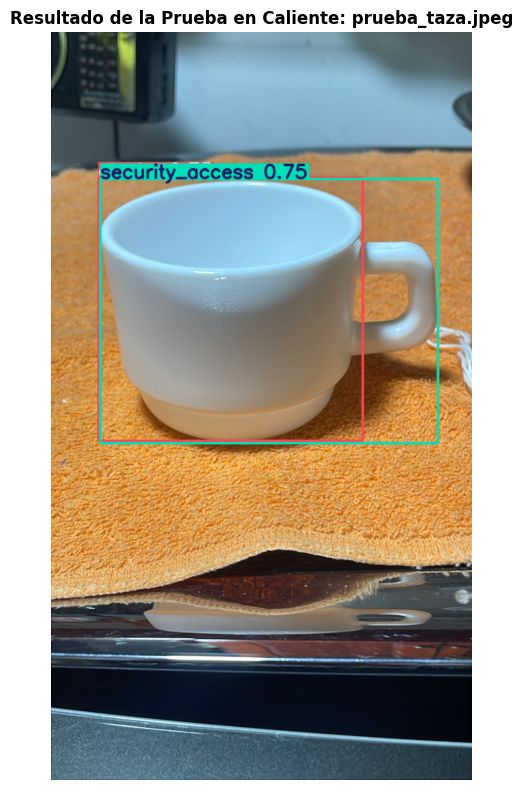

In [16]:
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from google.colab import files
from ultralytics import YOLO

# 1. Localizar dinámicamente el último modelo entrenado (8 clases)
train_dirs = sorted(glob.glob('./runs/detect/alarma_hogar*'), key=os.path.getmtime)
if not train_dirs:
    raise FileNotFoundError("No se encontró ningún entrenamiento previo de la alarma.")
best_weights_path = os.path.join(train_dirs[-1], 'weights', 'best.pt')
model_pt = YOLO(best_weights_path)

print("============================================================")
print("📸 ¡PRUEBA EN CALIENTE INTERACTIVA (8 CLASES)!")
print("Por favor, sube una foto de tu entorno para validar el modelo.")
print("Formatos sugeridos: Cuchillos, Llaves, Tazas, Microondas, Teléfonos...")
print("============================================================\n")

# Disparar interfaz interactiva de carga de archivos en el navegador
uploaded = files.upload()

if uploaded:
    # Capturar el nombre del archivo subido por el usuario
    imagen_usuario = list(uploaded.keys())[0]
    print(f"\n🔄 Procesando imagen subida en tiempo real: '{imagen_usuario}'...")

    # Ejecutar inferencia (guardamos en disco pero capturamos el objeto en memoria)
    results = model_pt.predict(source=imagen_usuario, conf=0.25, save=True, verbose=False)

    # --- SISTEMA DE RENDERIZADO CON CONTINGENCIA ---
    fig, ax = plt.subplots(figsize=(10, 8))

    try:
        # INTENTO A: Recuperar dinámicamente la carpeta guardada en disco por YOLO
        predict_dirs = sorted(glob.glob('./runs/detect/predict*'), key=os.path.getmtime)
        last_predict_dir = predict_dirs[-1]
        predicted_img_path = os.path.join(last_predict_dir, imagen_usuario)

        if os.path.exists(predicted_img_path):
            img = mpimg.imread(predicted_img_path)
            ax.imshow(img)
            print(f"✅ Imagen recuperada exitosamente desde disco ({last_predict_dir})")
        else:
            raise FileNotFoundError() # Forzar salto al plan de respaldo si no existe en la ruta esperada

    except Exception:
        # PLAN B (RESPALDO ABSOLUTO): Renderizar directamente los tensores de memoria RAM
        print("⚠️ Alerta: Desvío activado. Renderizando predicción directamente desde la memoria RAM...")
        # .plot() dibuja las cajas de las 8 clases en un array de numpy en formato BGR
        bgr_plot = results[0].plot()
        # Convertimos de BGR (formato OpenCV interno de YOLO) a RGB para Matplotlib
        rgb_plot = bgr_plot[:, :, ::-1]
        ax.imshow(rgb_plot)
        print("✅ Imagen visualizada correctamente desde los tensores de la red.")

    # Configuración de visualización limpia en pantalla
    ax.axis('off')
    plt.title(f"Resultado de la Prueba en Caliente: {imagen_usuario}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    print("❌ Operación cancelada. No se subió ninguna imagen para la prueba.")

In [22]:
%%writefile requirements.txt
ultralytics==8.3.0
gradio>=4.0.0
torch
torchvision
numpy
opencv-python-headless

Overwriting requirements.txt


In [23]:
%%writefile app.py
import gradio as gr
import numpy as np
from ultralytics import YOLO

# 1. Carga del modelo optimizado (Se asume que 'best.pt' estará en la raíz del espacio)
try:
    model = YOLO("best.pt")
    print("✅ Modelo cargado exitosamente en Hugging Face Spaces")
except Exception as e:
    print(f"❌ Error al cargar el modelo: {e}")

# 2. Configuración de la directiva de seguridad del hogar
# La macro-clase requerida para apagar la alarma.
OBJETO_REQUERIDO = "dishes_utensils"

def procesar_inferencia(imagen_entrada, conf_threshold, iou_threshold):
    if imagen_entrada is None:
        return None, "⚠️ Por favor, capture o suba una imagen primero.", "ESTADO: ESPERANDO ENTRADA"

    # Ejecutar el paso de predicción de la red neuronal
    results = model.predict(
        source=imagen_entrada,
        conf=conf_threshold,
        iou=iou_threshold,
        save=False,
        verbose=False
    )

    # Extraer el renderizado de las bounding boxes directamente de la memoria RAM (Formato BGR)
    img_bgr = results[0].plot()
    # Convertir canales de color para la compatibilidad nativa de Gradio (RGB)
    img_rgb = img_bgr[:, :, ::-1]

    # --- LÓGICA DE NEGOCIO: EVALUACIÓN DEL TOKEN VISUAL ---
    names = results[0].names
    alarma_apagada = False
    detecciones_texto = []

    for box in results[0].boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        label = names[class_id]

        detecciones_texto.append(f"• {label} (Confianza: {confidence:.2f})")

        if label == OBJETO_REQUERIDO:
            alarma_apagada = True

    # Formatear el reporte detallado para la interfaz de usuario
    if detecciones_texto:
        reporte_analisis = "🔍 **Objetos localizados en la escena:**\n" + "\n".join(detecciones_texto)
    else:
        reporte_analisis = "ℹ️ No se detectó ninguna de las 8 macro-clases en el umbral seleccionado."

    # Definir el estado lógico y el despliegue del indicador
    if alarma_apagada:
        estado_alarma = f"✅ SEGURIDAD COMPROBADA: '{OBJETO_REQUERIDO}' detectado.\n🔕 SISTEMA DE ALARMA: DESACTIVADO"
    else:
        estado_alarma = f"🚨 ALERTA INTRUSIÓN: No se visualiza el token de desbloqueo ('{OBJETO_REQUERIDO}').\n🔔 SISTEMA DE ALARMA: ACTIVADO / SONANDO"

    return img_rgb, reporte_analisis, estado_alarma

# 3. Diseño de la Interfaz Gráfica con Gradio
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# ⏰ Despertador Inteligente Anti-Snooze con IA (YOLOv11m)")
    gr.Markdown(
        "Prototipo de Visión por Computador con **YOLOv11 Medium** optimizado a **8 macro-clases** balanceadas. "
        "Mecanismo de desactivación condicional por Token Físico Visual."
    )

    with gr.Row():
        with gr.Column():
            # Widget de entrada adaptable a WebCam o subida de archivos estáticos
            input_image = gr.Image(sources=["webcam", "upload"], type="numpy", label="Captura del Sensor de Video")

            # Ajustes avanzados para que el profesor interactúe en vivo
            with gr.Accordion("Configuración del Modelo (Hiperparámetros)", open=False):
                conf_slider = gr.Slider(minimum=0.05, maximum=1.0, value=0.25, step=0.05, label="Umbral de Confianza (Confidence)")
                iou_slider = gr.Slider(minimum=0.1, maximum=1.0, value=0.6, step=0.05, label="Umbral NMS (IoU)")

            btn_predict = gr.Button("🚀 Analizar Escena", variant="primary")

        with gr.Column():
            # Canales de salida visual y textual
            output_image = gr.Image(type="numpy", label="Detección Multiescala (8 Clases)")
            output_status = gr.Textbox(label="Estado del Despertador (¿Apagado o Sonando?)", interactive=False)
            output_report = gr.Markdown(label="Telemetría de Objetos")

    # Enlace de eventos lógicos
    btn_predict.click(
        fn=procesar_inferencia,
        inputs=[input_image, conf_slider, iou_slider],
        outputs=[output_image, output_report, output_status]
    )

# Lanzamiento del servidor web
demo.launch()

Overwriting app.py
